# Spatial scan: SOC ground truth and fit comparison

Compare all 20 graphite/NMC cells using `generate_spatial_scan.py`, the spectra in `Data_NMC_simulated`, and the two requested AutoNRA TOML fit files.

Run all cells in order. Requires Python 3.11+, numpy, scipy, matplotlib, and the local ibeamlab package used by the generator. CSV, JSON and PNG results are saved in `datasets/NMC_simulated/SOC_comparison`.

Ground truth is reconstructed from the generator at the coordinates encoded in the spectrum filenames, assuming this generator matches the dataset. The measured counts identify the supplied raster; they are not independently refitted here.

In [1]:
from pathlib import Path
import csv
import json
import re
import runpy
import tomllib

import numpy as np
from scipy.special import erf
import matplotlib

import matplotlib.pyplot as plt

from IPython.display import display, Markdown

# Find the repository from either the notebook folder or the repository root.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "examples/generate_spatial_scan.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook within the iBeamLab repository.")
DATA = ROOT / "examples/datasets/NMC_simulated"
OUT = DATA / "SOC_comparison"
print(f"Dataset: {DATA}")

Dataset: D:\iBeamLab\examples\datasets\NMC_simulated


## Reconstruct fitted inventories

AutoNRA uses `abs(A * (1 + a * erf((u-b)/c)))` for these degree-zero profiles, normalized across elements at each sublayer midpoint. The implementation below reproduces its five logarithmic sublayers, checked against local AutoNRA `Parameterization.cpp` and `LayerModel.cpp`.

Integrate concentration times areal thickness. For graphite, **SOC = 6 Li/C**. For NMC, **SOC = (1 − Li/(Ni+Mn+Co))/0.7**, matching the generator's cathode range from Li₁ to Li₀.₃. Values are not clipped to 0–100%.

In [2]:
def read_fit(path):
    with path.open("rb") as stream:
        doc = tomllib.load(stream)
    config = doc["Config"]
    assert config["Layers"]["NumberOfLayers"] == 1
    assert config["Layers"]["Parameterization"] == ["Erf-polynomial"]
    assert config["Layers"]["Parameterization_Degree"] == [0]
    n = config["Layers"]["N_sublayers"][0]
    if config["Layers"]["Discretization_scaling"] == ["Log"]:
        edges = 4.0 ** np.linspace(-3, 0, n + 1)
        offset = edges[0]
        edges -= offset
        edges[-1] += offset
    else:
        edges = np.linspace(0, 1, n + 1)
    mids = (edges[:-1] + edges[1:]) / 2
    weights = np.diff(edges)
    defaults = {p[0]: p[1] for p in config["Analysis"]["Parameters"]}
    elements = [s.split(":")[0].strip() for s in config["Layers"]["ElementsPerLayer"][0].split(",")]
    results = {}
    for result in doc["BatchResults"]:
        p = defaults | result["Parameters"]
        profiles = []
        for element in elements:
            # Some element names include a leading space in the TOML keys.
            key = next(k[:-2] for k in p if re.fullmatch(r"Erf_1_\s*" + element + "_A", k))
            with np.errstate(divide="ignore", invalid="ignore"):
                z = (mids - p[key + "_b"]) / p[key + "_c"]
            profiles.append(np.abs(p[key + "_A"] * (1 + p[key + "_a"] * erf(z))))
        fractions = np.array(profiles).T
        fractions /= fractions.sum(axis=1, keepdims=True)
        assert np.isfinite(fractions).all()
        # Retain the actual discretized layer stack for depth-profile comparisons.
        result["profile_edges"] = edges * p["Thickness_1"]
        result["profile_fractions"] = fractions
        result["profile_elements"] = elements
        inventory = weights @ fractions * p["Thickness_1"]
        assert result["Sample"] not in results
        results[result["Sample"]] = (dict(zip(elements, inventory)), result)
    return results


def soc(inventory, anode):
    li = inventory["Li"]
    host = inventory["C"] if anode else sum(inventory[e] for e in ("Ni", "Mn", "Co"))
    x = 6 * li / host if anode else li / host
    return x if anode else (1 - x) / 0.7


def write_csv(path, rows):
    with path.open("w", newline="", encoding="utf-8") as stream:
        writer = csv.DictWriter(stream, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)

## Load and validate the scan and both fits

Require an exact match between measured spectrum names and fit results.

In [3]:
model = runpy.run_path(str(ROOT / "examples/generate_spatial_scan.py"))
cells = model["array_cell_layout"]()
fit_paths = {"SIMNRA": DATA / "SIMNRA_fit/ref.anra", "LRN": DATA / "LRN_fit/ref_lrn.anra"}
fits = {method: read_fit(p) for method, p in fit_paths.items()}
import hashlib
provenance = {method: {"path": str(p), "sha256": hashlib.sha256(p.read_bytes()).hexdigest()} for method, p in fit_paths.items()}
OUT.mkdir(exist_ok=True)
(OUT / "input_provenance.json").write_text(json.dumps(provenance, indent=2))
for method, details in provenance.items():
    print(f"{method}: {details['path']} (SHA256 {details['sha256'][:12]})")
files = sorted((DATA / "Data_NMC_simulated").glob("*_RBS.dat"))
names = {p.stem.removesuffix("_RBS") for p in files}
for fit in fits.values():
    assert set(fit) == names, "Fit and measured raster positions differ"
thickness = model["sublayer_thicknesses"]()
elements = model["ARRAY_ELEMENTS"]

print(f"Matched {len(files):,} spectra in each fit.")

SIMNRA: D:\iBeamLab\examples\datasets\NMC_simulated\SIMNRA_fit\ref.anra (SHA256 72607490dc56)
LRN: D:\iBeamLab\examples\datasets\NMC_simulated\LRN_fit\ref_lrn.anra (SHA256 ab097fa7ba0f)
Matched 10,000 spectra in each fit.


## Estimate SOC at each electrode position

Use 5 mm circular masks from the generator and exclude the aluminum holder. Ground truth integrates the generator's ten geometric sublayers.

In [4]:
points = []
inventories = {}
for path in files:
    name = path.stem.removesuffix("_RBS")
    parts = name.rsplit("_", 4)
    x, y = int(parts[1]) / 1e6, int(parts[3]) / 1e6
    cell_id = int(model["_array_cell_ids"](np.array(x), np.array(y)))
    if cell_id < 0:
        continue
    cell = cells[cell_id]
    inv = dict(zip(elements, thickness @ model["array_sublayer_compositions"](x, y)))
    record = {"sample": name, "cell_id": cell_id, "x_mm": x, "y_mm": y,
              "nominal_soc_pct": 100 * cell["soc"], "truth_local_soc_pct": 100 * soc(inv, cell["electrode"] == "anode")}
    inventories[name] = {"truth": inv}
    for method, fit in fits.items():
        inventories[name][method] = fit[name][0]
        record[method + "_soc_pct"] = 100 * soc(fit[name][0], cell["electrode"] == "anode")
        record[method + "_chi2"] = fit[name][1]["Chi2"]
        record[method + "_status"] = fit[name][1]["Status"]
    points.append(record)

print(f"Retained {len(points):,} electrode positions; excluded {len(files)-len(points):,} holder positions.")

Retained 6,124 electrode positions; excluded 3,876 holder positions.


## Estimate SOC of each cell

Pool lithium and host inventories across all positions before calculating each cell's SOC. This differs from averaging local SOC ratios. Raster-derived ground truth differs slightly from nominal SOC because the finite grid samples a radial gradient. Errors below use raster-derived truth; `pp` means percentage points.

In [5]:
rows = []
for cell in cells:
    subset = [p for p in points if p["cell_id"] == cell["cell_id"]]
    row = {"cell_id": cell["cell_id"], "chemistry": cell["chemistry"], "column": cell["column"] + 1,
           "n_positions": len(subset), "nominal_soc_pct": 100 * cell["soc"]}
    for method in ("truth", "SIMNRA", "LRN"):
        pooled = {e: sum(inventories[p["sample"]][method][e] for p in subset) for e in elements}
        row[method + "_soc_pct"] = 100 * soc(pooled, cell["electrode"] == "anode")
        if method != "truth":
            row[method + "_error_pp"] = row[method + "_soc_pct"] - row["truth_soc_pct"]
            errors = np.array([p[method + "_soc_pct"] - p["truth_local_soc_pct"] for p in subset])
            row[method + "_pixel_rmse_pp"] = float(np.sqrt(np.mean(errors ** 2)))
            row[method + "_outside_range_positions"] = sum(not 0 <= p[method + "_soc_pct"] <= 100 for p in subset)
    rows.append(row)


In [6]:
columns = ["chemistry", "column", "n_positions", "nominal_soc_pct", "truth_soc_pct", "SIMNRA_soc_pct", "LRN_soc_pct", "SIMNRA_error_pp", "LRN_error_pp"]
header = "| " + " | ".join(columns) + " |\n| " + " | ".join(["---"] * len(columns)) + " |\n"
lines = []
for row in rows:
    values = [f"{row[k]:.2f}" if isinstance(row[k], float) else str(row[k]) for k in columns]
    lines.append("| " + " | ".join(values) + " |")
display(Markdown(header + "\n".join(lines)))

| chemistry | column | n_positions | nominal_soc_pct | truth_soc_pct | SIMNRA_soc_pct | LRN_soc_pct | SIMNRA_error_pp | LRN_error_pp |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Graphite | 1 | 307 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 |
| Graphite | 2 | 303 | 25.00 | 25.03 | 23.89 | 24.76 | -1.13 | -0.26 |
| Graphite | 3 | 308 | 50.00 | 49.93 | 48.47 | 48.45 | -1.46 | -1.48 |
| Graphite | 4 | 303 | 75.00 | 75.06 | 73.90 | 73.31 | -1.17 | -1.75 |
| Graphite | 5 | 307 | 100.00 | 100.00 | 98.94 | 98.66 | -1.06 | -1.34 |
| NMC111 | 1 | 307 | 0.00 | 0.00 | 2.02 | 3.32 | 2.02 | 3.32 |
| NMC111 | 2 | 305 | 25.00 | 24.98 | 25.70 | 25.87 | 0.71 | 0.88 |
| NMC111 | 3 | 310 | 50.00 | 50.21 | 49.92 | 49.71 | -0.29 | -0.49 |
| NMC111 | 4 | 305 | 75.00 | 74.98 | 75.06 | 74.90 | 0.08 | -0.08 |
| NMC111 | 5 | 307 | 100.00 | 100.00 | 101.42 | 100.62 | 1.42 | 0.62 |
| NMC622 | 1 | 307 | 0.00 | 0.00 | 1.94 | 3.16 | 1.94 | 3.16 |
| NMC622 | 2 | 305 | 25.00 | 24.98 | 26.00 | 26.25 | 1.02 | 1.27 |
| NMC622 | 3 | 310 | 50.00 | 50.21 | 50.54 | 49.84 | 0.34 | -0.37 |
| NMC622 | 4 | 305 | 75.00 | 74.98 | 75.43 | 75.22 | 0.45 | 0.24 |
| NMC622 | 5 | 307 | 100.00 | 100.00 | 101.45 | 100.62 | 1.45 | 0.62 |
| NMC811 | 1 | 307 | 0.00 | 0.00 | 2.04 | 2.66 | 2.04 | 2.66 |
| NMC811 | 2 | 303 | 25.00 | 24.94 | 26.10 | 26.54 | 1.16 | 1.60 |
| NMC811 | 3 | 308 | 50.00 | 50.11 | 50.67 | 50.14 | 0.55 | 0.02 |
| NMC811 | 4 | 303 | 75.00 | 74.92 | 75.39 | 75.41 | 0.46 | 0.48 |
| NMC811 | 5 | 307 | 100.00 | 100.00 | 101.42 | 100.57 | 1.42 | 0.57 |

## Compare accuracy and export results

Cell MAE, RMSE and bias treat each cell equally. Per-position errors and out-of-range counts are also exported. No statistical confidence intervals are inferred.

In [7]:
OUT.mkdir(exist_ok=True)
write_csv(OUT / "cell_soc.csv", rows)
write_csv(OUT / "position_soc.csv", points)
metrics = {}
for method in fits:
    metrics[method] = {}
    for chemistry in ("all", "Graphite", "NMC111", "NMC622", "NMC811"):
        selected = [r for r in rows if chemistry == "all" or r["chemistry"] == chemistry]
        errors = np.array([r[method + "_error_pp"] for r in selected])
        metrics[method][chemistry] = {"cell_mae_pp": float(np.mean(abs(errors))),
                                    "cell_rmse_pp": float(np.sqrt(np.mean(errors**2))),
                                    "cell_bias_pp": float(np.mean(errors))}
(OUT / "metrics.json").write_text(json.dumps(metrics, indent=2))

lines = ["| Scope | SIMNRA MAE (pp) | LRN MAE (pp) |", "|---|---:|---:|"]
for scope in ("all", "Graphite", "NMC111", "NMC622", "NMC811"):
    lines.append(f"| {scope} | {metrics['SIMNRA'][scope]['cell_mae_pp']:.3f} | {metrics['LRN'][scope]['cell_mae_pp']:.3f} |")
display(Markdown("\n".join(lines)))
print(f"Exports saved to: {OUT}")

| Scope | SIMNRA MAE (pp) | LRN MAE (pp) |
|---|---:|---:|
| all | 1.008 | 1.062 |
| Graphite | 0.963 | 0.968 |
| NMC111 | 0.903 | 1.079 |
| NMC622 | 1.040 | 1.133 |
| NMC811 | 1.126 | 1.068 |

Exports saved to: D:\iBeamLab\examples\datasets\NMC_simulated\SOC_comparison


## Plot the cell estimates

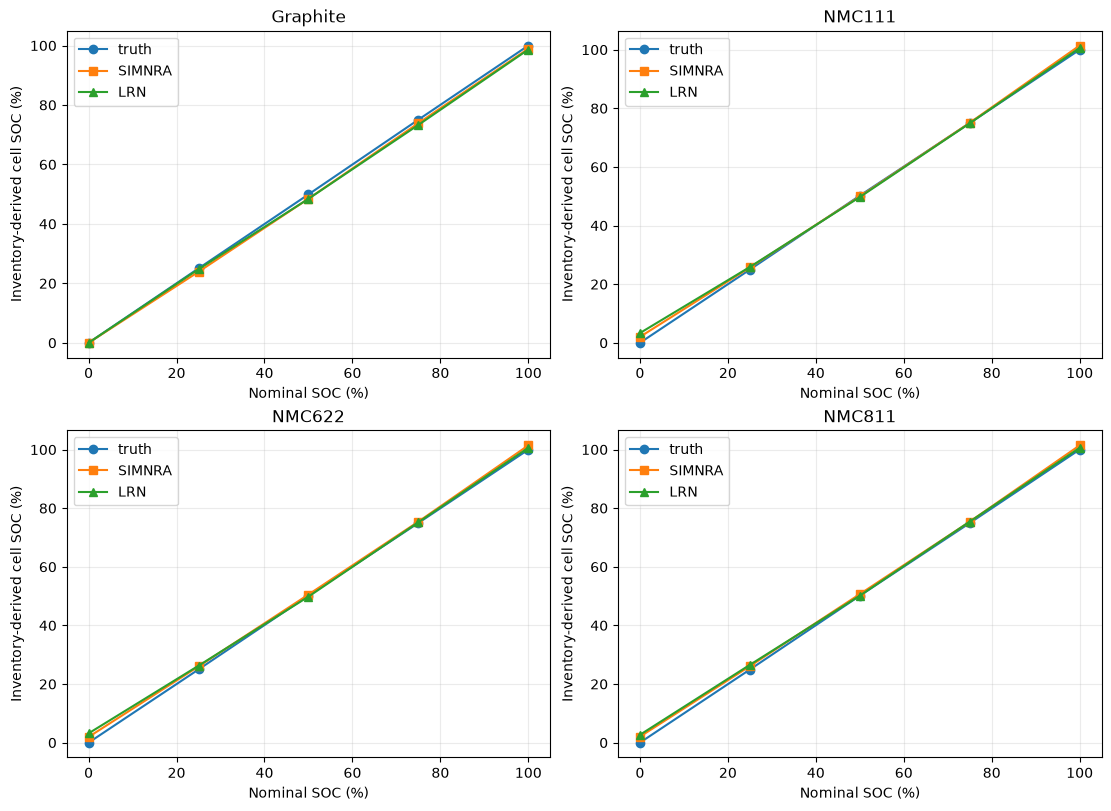

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for ax, chemistry in zip(axes.flat, ("Graphite", "NMC111", "NMC622", "NMC811")):
    selected = [r for r in rows if r["chemistry"] == chemistry]
    for method, marker in (("truth", "o"), ("SIMNRA", "s"), ("LRN", "^")):
        ax.plot([r["nominal_soc_pct"] for r in selected], [r[method + "_soc_pct"] for r in selected], marker=marker, label=method)
    ax.set(title=chemistry, xlabel="Nominal SOC (%)", ylabel="Inventory-derived cell SOC (%)")
    ax.grid(alpha=.25)
    ax.legend()
fig.savefig(OUT / "cell_soc_comparison.png", dpi=180)

plt.show()


In [9]:
lines = ["## SOC accuracy for the currently loaded fits", "", "| Scope | SIMNRA cell MAE (pp) | LRN cell MAE (pp) |", "|---|---:|---:|"]
for scope in ("all", "Graphite", "NMC111", "NMC622", "NMC811"):
    lines.append(f"| {scope} | {metrics['SIMNRA'][scope]['cell_mae_pp']:.3f} | {metrics['LRN'][scope]['cell_mae_pp']:.3f} |")
display(Markdown("\n".join(lines)))

## SOC accuracy for the currently loaded fits

| Scope | SIMNRA cell MAE (pp) | LRN cell MAE (pp) |
|---|---:|---:|
| all | 1.008 | 1.062 |
| Graphite | 0.963 | 0.968 |
| NMC111 | 0.903 | 1.079 |
| NMC622 | 1.040 | 1.133 |
| NMC811 | 1.126 | 1.068 |

## Recovering Mn, Ni, Co and O stoichiometry

For LiₓNiₐMnᵦCo𝒸O₂, a+b+c=1. The atomic fractions are Ni=a/(x+3), Mn=b/(x+3), Co=c/(x+3), O=2/(x+3). The generator uses x=1−0.7 SOC for the mean composition, with spatial lithium gradients. We compare against the exact raster-integrated ground truth.

Two checks answer different questions:
- **Absolute atomic fractions:** divide each pooled element inventory by the inventory of all elements, including fitted Li, C and Al. Errors are percentage points of atomic fraction.
- **Host stoichiometry:** Ni/TM=a, Mn/TM=b, Co/TM=c, O/TM=2, where TM=Ni+Mn+Co. These ratios reveal whether the NMC formula is recovered independently of lithium. Errors in these ratios are dimensionless.

Neither estimate is forced to match the chemical formula. Each NMC cell has equal weight in the summary; per-position errors are also exported. Graphite has zero ground-truth Mn, Ni, Co and O, so it is excluded from the NMC stoichiometry assessment.

Li and cathode C are also included in the absolute-fraction comparison and exports. For Li/TM, the reference is the cell's raster-integrated ground-truth ratio; for C/TM, the reference is zero. The fixed host-stoichiometry plots remain Mn, Ni, Co and O.

In [10]:
host_species = ("Mn", "Ni", "Co", "O")
species_to_check = ("Li", "Mn", "Ni", "Co", "O", "C")
composition_rows = []
position_composition_rows = []
for cell in cells:
    subset = [p for p in points if p["cell_id"] == cell["cell_id"]]
    is_cathode = cell["electrode"] == "cathode"
    expected_ratios = {e: float("nan") for e in species_to_check}
    if is_cathode:
        a, b, c = model["ARRAY_NMC_COMPOSITIONS"][cell["chemistry"]]
        expected_ratios.update({"Ni": a, "Mn": b, "Co": c, "O": 2.0})
    pooled = {method: {e: sum(inventories[p["sample"]][method][e] for p in subset)
                       for e in elements} for method in ("truth", "SIMNRA", "LRN")}
    # Li varies with SOC and the sampled radial profile; C is absent in cathode truth.
    truth_tm = sum(pooled["truth"][e] for e in ("Ni", "Mn", "Co"))
    if is_cathode:
        expected_ratios.update({"Li": pooled["truth"]["Li"] / truth_tm, "C": 0.0})
    for element in species_to_check:
        row = {"cell_id": cell["cell_id"], "chemistry": cell["chemistry"],
               "column": cell["column"] + 1, "nominal_soc_pct": 100 * cell["soc"],
               "element": element, "formula_host_ratio": expected_ratios[element]}
        for method, inv in pooled.items():
            row[method + "_atomic_pct"] = 100 * inv[element] / sum(inv.values())
            row[method + "_host_ratio"] = inv[element] / sum(inv[e] for e in ("Ni", "Mn", "Co")) if is_cathode else float("nan")
        if is_cathode:
            assert np.isclose(row["truth_host_ratio"], expected_ratios[element])
        for method in fits:
            row[method + "_atomic_error_pp"] = row[method + "_atomic_pct"] - row["truth_atomic_pct"]
            row[method + "_host_ratio_error"] = row[method + "_host_ratio"] - expected_ratios[element]
        composition_rows.append(row)
    for p in subset:
        for element in species_to_check:
            row = {"sample": p["sample"], "cell_id": cell["cell_id"], "chemistry": cell["chemistry"], "element": element}
            for method, inv in inventories[p["sample"]].items():
                row[method + "_atomic_pct"] = 100 * inv[element] / sum(inv.values())
                row[method + "_host_ratio"] = inv[element] / sum(inv[e] for e in ("Ni", "Mn", "Co")) if is_cathode else float("nan")
            for method in fits:
                row[method + "_atomic_error_pp"] = row[method + "_atomic_pct"] - row["truth_atomic_pct"]
                row[method + "_host_ratio_error"] = row[method + "_host_ratio"] - row["truth_host_ratio"]
            position_composition_rows.append(row)
write_csv(OUT / "cell_element_fractions.csv", composition_rows)
write_csv(OUT / "position_element_fractions.csv", position_composition_rows)

# Full per-cell atomic-fraction comparison.
lines = ["| Chemistry | Column | SOC (%) | Element | Truth (at.%) | SIMNRA (at.%) | LRN (at.%) |", "|---|---:|---:|---|---:|---:|---:|"]
for r in composition_rows:
    lines.append(f"| {r['chemistry']} | {r['column']} | {r['nominal_soc_pct']:.0f} | {r['element']} | {r['truth_atomic_pct']:.3f} | {r['SIMNRA_atomic_pct']:.3f} | {r['LRN_atomic_pct']:.3f} |")
display(Markdown("\n".join(lines)))

| Chemistry | Column | SOC (%) | Element | Truth (at.%) | SIMNRA (at.%) | LRN (at.%) |
|---|---:|---:|---|---:|---:|---:|
| Graphite | 1 | 0 | Li | 0.000 | 0.000 | 0.000 |
| Graphite | 1 | 0 | Mn | 0.000 | 0.000 | 0.000 |
| Graphite | 1 | 0 | Ni | 0.000 | 0.000 | 0.000 |
| Graphite | 1 | 0 | Co | 0.000 | 0.000 | 0.000 |
| Graphite | 1 | 0 | O | 0.000 | 0.000 | 0.000 |
| Graphite | 1 | 0 | C | 100.000 | 100.000 | 100.000 |
| Graphite | 2 | 25 | Li | 4.004 | 3.830 | 3.964 |
| Graphite | 2 | 25 | Mn | 0.000 | 0.000 | 0.000 |
| Graphite | 2 | 25 | Ni | 0.000 | 0.000 | 0.000 |
| Graphite | 2 | 25 | Co | 0.000 | 0.000 | 0.000 |
| Graphite | 2 | 25 | O | 0.000 | 0.000 | 0.002 |
| Graphite | 2 | 25 | C | 95.996 | 96.169 | 96.034 |
| Graphite | 3 | 50 | Li | 7.682 | 7.474 | 7.471 |
| Graphite | 3 | 50 | Mn | 0.000 | 0.000 | 0.004 |
| Graphite | 3 | 50 | Ni | 0.000 | 0.001 | 0.001 |
| Graphite | 3 | 50 | Co | 0.000 | 0.000 | 0.002 |
| Graphite | 3 | 50 | O | 0.000 | 0.001 | 0.000 |
| Graphite | 3 | 50 | C | 92.318 | 92.523 | 92.522 |
| Graphite | 4 | 75 | Li | 11.119 | 10.965 | 10.886 |
| Graphite | 4 | 75 | Mn | 0.000 | 0.000 | 0.013 |
| Graphite | 4 | 75 | Ni | 0.000 | 0.000 | 0.000 |
| Graphite | 4 | 75 | Co | 0.000 | 0.000 | 0.001 |
| Graphite | 4 | 75 | O | 0.000 | 0.000 | 0.000 |
| Graphite | 4 | 75 | C | 88.881 | 89.033 | 89.099 |
| Graphite | 5 | 100 | Li | 14.286 | 14.156 | 14.121 |
| Graphite | 5 | 100 | Mn | 0.000 | 0.000 | 0.000 |
| Graphite | 5 | 100 | Ni | 0.000 | 0.000 | 0.000 |
| Graphite | 5 | 100 | Co | 0.000 | 0.000 | 0.000 |
| Graphite | 5 | 100 | O | 0.000 | 0.000 | 0.000 |
| Graphite | 5 | 100 | C | 85.714 | 85.844 | 85.879 |
| NMC111 | 1 | 0 | Li | 25.000 | 24.797 | 24.617 |
| NMC111 | 1 | 0 | Mn | 8.333 | 8.498 | 8.798 |
| NMC111 | 1 | 0 | Ni | 8.333 | 6.821 | 5.697 |
| NMC111 | 1 | 0 | Co | 8.333 | 9.833 | 10.708 |
| NMC111 | 1 | 0 | O | 50.000 | 49.997 | 50.042 |
| NMC111 | 1 | 0 | C | 0.000 | 0.019 | 0.016 |
| NMC111 | 2 | 25 | Li | 21.571 | 21.394 | 21.270 |
| NMC111 | 2 | 25 | Mn | 8.714 | 8.612 | 9.049 |
| NMC111 | 2 | 25 | Ni | 8.714 | 7.371 | 11.220 |
| NMC111 | 2 | 25 | Co | 8.714 | 10.104 | 5.704 |
| NMC111 | 2 | 25 | O | 52.286 | 51.801 | 52.266 |
| NMC111 | 2 | 25 | C | 0.000 | 0.651 | 0.144 |
| NMC111 | 3 | 50 | Li | 17.776 | 17.608 | 17.600 |
| NMC111 | 3 | 50 | Mn | 9.136 | 8.640 | 9.561 |
| NMC111 | 3 | 50 | Ni | 9.136 | 8.898 | 15.309 |
| NMC111 | 3 | 50 | Co | 9.136 | 9.527 | 2.123 |
| NMC111 | 3 | 50 | O | 54.816 | 53.380 | 54.812 |
| NMC111 | 3 | 50 | C | 0.000 | 1.884 | 0.210 |
| NMC111 | 4 | 75 | Li | 13.673 | 13.525 | 13.487 |
| NMC111 | 4 | 75 | Mn | 9.592 | 9.277 | 9.993 |
| NMC111 | 4 | 75 | Ni | 9.592 | 9.791 | 15.120 |
| NMC111 | 4 | 75 | Co | 9.592 | 9.430 | 3.240 |
| NMC111 | 4 | 75 | O | 57.552 | 56.467 | 57.736 |
| NMC111 | 4 | 75 | C | 0.000 | 1.427 | 0.160 |
| NMC111 | 5 | 100 | Li | 9.091 | 8.832 | 8.719 |
| NMC111 | 5 | 100 | Mn | 10.101 | 10.261 | 8.448 |
| NMC111 | 5 | 100 | Ni | 10.101 | 8.607 | 11.682 |
| NMC111 | 5 | 100 | Co | 10.101 | 11.580 | 9.359 |
| NMC111 | 5 | 100 | O | 60.606 | 60.484 | 60.368 |
| NMC111 | 5 | 100 | C | 0.000 | 0.199 | 0.224 |
| NMC622 | 1 | 0 | Li | 25.000 | 24.798 | 24.595 |
| NMC622 | 1 | 0 | Mn | 5.000 | 5.153 | 5.068 |
| NMC622 | 1 | 0 | Ni | 15.000 | 13.618 | 11.249 |
| NMC622 | 1 | 0 | Co | 5.000 | 6.369 | 8.835 |
| NMC622 | 1 | 0 | O | 50.000 | 50.012 | 50.047 |
| NMC622 | 1 | 0 | C | 0.000 | 0.011 | 0.006 |
| NMC622 | 2 | 25 | Li | 21.571 | 21.376 | 21.275 |
| NMC622 | 2 | 25 | Mn | 5.229 | 5.183 | 5.685 |
| NMC622 | 2 | 25 | Ni | 15.686 | 13.864 | 17.046 |
| NMC622 | 2 | 25 | Co | 5.229 | 7.086 | 3.333 |
| NMC622 | 2 | 25 | O | 52.286 | 51.607 | 52.181 |
| NMC622 | 2 | 25 | C | 0.000 | 0.857 | 0.149 |
| NMC622 | 3 | 50 | Li | 17.776 | 17.658 | 17.640 |
| NMC622 | 3 | 50 | Mn | 5.482 | 5.335 | 5.969 |
| NMC622 | 3 | 50 | Ni | 16.445 | 14.553 | 20.703 |
| NMC622 | 3 | 50 | Co | 5.482 | 7.437 | 0.420 |
| NMC622 | 3 | 50 | O | 54.816 | 54.151 | 54.689 |
| NMC622 | 3 | 50 | C | 0.000 | 0.818 | 0.222 |
| NMC622 | 4 | 75 | Li | 13.673 | 13.519 | 13.466 |
| NMC622 | 4 | 75 | Mn | 5.755 | 5.502 | 6.373 |
| NMC622 | 4 | 75 | Ni | 17.265 | 15.381 | 21.604 |
| NMC622 | 4 | 75 | Co | 5.755 | 7.760 | 0.464 |
| NMC622 | 4 | 75 | O | 57.552 | 56.378 | 57.786 |
| NMC622 | 4 | 75 | C | 0.000 | 1.408 | 0.113 |
| NMC622 | 5 | 100 | Li | 9.091 | 8.824 | 8.707 |
| NMC622 | 5 | 100 | Mn | 6.061 | 6.147 | 4.680 |
| NMC622 | 5 | 100 | Ni | 18.182 | 16.505 | 21.168 |
| NMC622 | 5 | 100 | Co | 6.061 | 7.792 | 3.605 |
| NMC622 | 5 | 100 | O | 60.606 | 60.391 | 60.578 |
| NMC622 | 5 | 100 | C | 0.000 | 0.302 | 0.234 |
| NMC811 | 1 | 0 | Li | 25.000 | 24.789 | 24.604 |
| NMC811 | 1 | 0 | Mn | 2.500 | 2.628 | 2.483 |
| NMC811 | 1 | 0 | Ni | 20.000 | 18.412 | 16.074 |
| NMC811 | 1 | 0 | Co | 2.500 | 4.107 | 6.515 |
| NMC811 | 1 | 0 | O | 50.000 | 49.970 | 50.044 |
| NMC811 | 1 | 0 | C | 0.000 | 0.054 | 0.002 |
| NMC811 | 2 | 25 | Li | 21.578 | 21.417 | 21.302 |
| NMC811 | 2 | 25 | Mn | 2.614 | 2.592 | 3.192 |
| NMC811 | 2 | 25 | Ni | 20.913 | 18.516 | 21.131 |
| NMC811 | 2 | 25 | Co | 2.614 | 5.097 | 1.838 |
| NMC811 | 2 | 25 | O | 52.282 | 51.927 | 52.094 |
| NMC811 | 2 | 25 | C | 0.000 | 0.415 | 0.138 |
| NMC811 | 3 | 50 | Li | 17.790 | 17.679 | 17.664 |
| NMC811 | 3 | 50 | Mn | 2.740 | 2.681 | 3.210 |
| NMC811 | 3 | 50 | Ni | 21.923 | 19.247 | 23.813 |
| NMC811 | 3 | 50 | Co | 2.740 | 5.467 | 0.193 |
| NMC811 | 3 | 50 | O | 54.807 | 54.352 | 54.617 |
| NMC811 | 3 | 50 | C | 0.000 | 0.529 | 0.212 |
| NMC811 | 4 | 75 | Li | 13.683 | 13.566 | 13.469 |
| NMC811 | 4 | 75 | Mn | 2.877 | 2.836 | 3.215 |
| NMC811 | 4 | 75 | Ni | 23.018 | 21.304 | 24.942 |
| NMC811 | 4 | 75 | Co | 2.877 | 4.583 | 0.369 |
| NMC811 | 4 | 75 | O | 57.545 | 57.005 | 57.648 |
| NMC811 | 4 | 75 | C | 0.000 | 0.649 | 0.091 |
| NMC811 | 5 | 100 | Li | 9.091 | 8.816 | 8.715 |
| NMC811 | 5 | 100 | Mn | 3.030 | 3.105 | 1.971 |
| NMC811 | 5 | 100 | Ni | 24.242 | 22.590 | 27.229 |
| NMC811 | 5 | 100 | Co | 3.030 | 4.696 | 0.240 |
| NMC811 | 5 | 100 | O | 60.606 | 60.076 | 60.638 |
| NMC811 | 5 | 100 | C | 0.000 | 0.680 | 0.211 |

## Element recovery errors

MAE and RMSE below use the 15 NMC cell inventories. Pixel RMSE checks local recovery without cancellation across a cell. Small cell-average errors alone do not guarantee accurate local composition.

In [11]:
element_metrics = []
for scope in ("all NMC", "Graphite", "NMC111", "NMC622", "NMC811"):
    for element in species_to_check:
        selected = [r for r in composition_rows if r["element"] == element and ((scope == "all NMC" and r["chemistry"] != "Graphite") or r["chemistry"] == scope)]
        pixels = [r for r in position_composition_rows if r["element"] == element and ((scope == "all NMC" and r["chemistry"] != "Graphite") or r["chemistry"] == scope)]
        for method in fits:
            errors = np.array([r[method + "_atomic_error_pp"] for r in selected])
            ratio_errors = np.array([r[method + "_host_ratio_error"] for r in selected])
            pixel_errors = np.array([r[method + "_atomic_error_pp"] for r in pixels])
            element_metrics.append({"scope": scope, "element": element, "method": method,
                "cell_atomic_mae_pp": float(np.mean(abs(errors))),
                "cell_atomic_rmse_pp": float(np.sqrt(np.mean(errors**2))),
                "cell_atomic_bias_pp": float(np.mean(errors)),
                "pixel_atomic_rmse_pp": float(np.sqrt(np.mean(pixel_errors**2))),
                "cell_host_ratio_mae": float(np.mean(abs(ratio_errors))),
                "cell_host_ratio_bias": float(np.mean(ratio_errors))})
write_csv(OUT / "element_recovery_metrics.csv", element_metrics)
lines = ["| Scope | Element | Method | Cell MAE (pp) | Cell RMSE (pp) | Pixel RMSE (pp) | Host ratio MAE |", "|---|---|---|---:|---:|---:|---:|"]
for r in element_metrics:
    lines.append(f"| {r['scope']} | {r['element']} | {r['method']} | {r['cell_atomic_mae_pp']:.3f} | {r['cell_atomic_rmse_pp']:.3f} | {r['pixel_atomic_rmse_pp']:.3f} | {r['cell_host_ratio_mae']:.4f} |")
display(Markdown("\n".join(lines)))

| Scope | Element | Method | Cell MAE (pp) | Cell RMSE (pp) | Pixel RMSE (pp) | Host ratio MAE |
|---|---|---|---:|---:|---:|---:|
| all NMC | Li | SIMNRA | 0.184 | 0.191 | 0.251 | 0.0072 |
| all NMC | Li | LRN | 0.282 | 0.299 | 0.309 | 0.0077 |
| all NMC | Mn | SIMNRA | 0.150 | 0.192 | 1.054 | 0.0044 |
| all NMC | Mn | LRN | 0.583 | 0.727 | 0.809 | 0.0206 |
| all NMC | Ni | SIMNRA | 1.565 | 1.687 | 3.114 | 0.0579 |
| all NMC | Ni | LRN | 3.071 | 3.443 | 3.750 | 0.1195 |
| all NMC | Co | SIMNRA | 1.602 | 1.724 | 3.145 | 0.0583 |
| all NMC | Co | LRN | 3.378 | 3.830 | 4.166 | 0.1217 |
| all NMC | O | SIMNRA | 0.519 | 0.670 | 3.454 | 0.0183 |
| all NMC | O | LRN | 0.106 | 0.132 | 0.214 | 0.0240 |
| all NMC | C | SIMNRA | 0.660 | 0.851 | 4.197 | 0.0238 |
| all NMC | C | LRN | 0.142 | 0.163 | 0.176 | 0.0051 |
| Graphite | Li | SIMNRA | 0.133 | 0.151 | 0.168 | nan |
| Graphite | Li | LRN | 0.130 | 0.160 | 0.181 | nan |
| Graphite | Mn | SIMNRA | 0.000 | 0.000 | 0.001 | nan |
| Graphite | Mn | LRN | 0.004 | 0.006 | 0.010 | nan |
| Graphite | Ni | SIMNRA | 0.000 | 0.000 | 0.003 | nan |
| Graphite | Ni | LRN | 0.000 | 0.001 | 0.002 | nan |
| Graphite | Co | SIMNRA | 0.000 | 0.000 | 0.001 | nan |
| Graphite | Co | LRN | 0.000 | 0.001 | 0.002 | nan |
| Graphite | O | SIMNRA | 0.000 | 0.001 | 0.001 | nan |
| Graphite | O | LRN | 0.000 | 0.001 | 0.003 | nan |
| Graphite | C | SIMNRA | 0.132 | 0.150 | 0.165 | nan |
| Graphite | C | LRN | 0.125 | 0.153 | 0.175 | nan |
| NMC111 | Li | SIMNRA | 0.191 | 0.195 | 0.266 | 0.0063 |
| NMC111 | Li | LRN | 0.284 | 0.297 | 0.307 | 0.0076 |
| NMC111 | Mn | SIMNRA | 0.248 | 0.286 | 1.454 | 0.0067 |
| NMC111 | Mn | LRN | 0.656 | 0.825 | 0.883 | 0.0235 |
| NMC111 | Ni | SIMNRA | 0.957 | 1.133 | 3.185 | 0.0357 |
| NMC111 | Ni | LRN | 3.685 | 4.108 | 4.421 | 0.1405 |
| NMC111 | Co | SIMNRA | 0.984 | 1.144 | 2.994 | 0.0359 |
| NMC111 | Co | LRN | 3.898 | 4.578 | 4.920 | 0.1390 |
| NMC111 | O | SIMNRA | 0.626 | 0.835 | 3.754 | 0.0172 |
| NMC111 | O | LRN | 0.098 | 0.136 | 0.216 | 0.0282 |
| NMC111 | C | SIMNRA | 0.836 | 1.100 | 4.706 | 0.0304 |
| NMC111 | C | LRN | 0.151 | 0.168 | 0.181 | 0.0054 |
| NMC622 | Li | SIMNRA | 0.187 | 0.194 | 0.256 | 0.0073 |
| NMC622 | Li | LRN | 0.285 | 0.303 | 0.314 | 0.0079 |
| NMC622 | Mn | SIMNRA | 0.137 | 0.154 | 0.971 | 0.0042 |
| NMC622 | Mn | LRN | 0.602 | 0.740 | 0.834 | 0.0210 |
| NMC622 | Ni | SIMNRA | 1.732 | 1.742 | 3.037 | 0.0632 |
| NMC622 | Ni | LRN | 3.339 | 3.515 | 3.756 | 0.1299 |
| NMC622 | Co | SIMNRA | 1.783 | 1.798 | 3.138 | 0.0647 |
| NMC622 | Co | LRN | 3.708 | 3.948 | 4.216 | 0.1338 |
| NMC622 | O | SIMNRA | 0.549 | 0.682 | 3.547 | 0.0204 |
| NMC622 | O | LRN | 0.108 | 0.131 | 0.209 | 0.0239 |
| NMC622 | C | SIMNRA | 0.679 | 0.834 | 4.258 | 0.0245 |
| NMC622 | C | LRN | 0.145 | 0.167 | 0.180 | 0.0052 |
| NMC811 | Li | SIMNRA | 0.175 | 0.185 | 0.229 | 0.0079 |
| NMC811 | Li | LRN | 0.277 | 0.295 | 0.305 | 0.0075 |
| NMC811 | Mn | SIMNRA | 0.065 | 0.075 | 0.523 | 0.0022 |
| NMC811 | Mn | LRN | 0.492 | 0.599 | 0.698 | 0.0173 |
| NMC811 | Ni | SIMNRA | 2.005 | 2.054 | 3.118 | 0.0747 |
| NMC811 | Ni | LRN | 2.189 | 2.516 | 2.920 | 0.0882 |
| NMC811 | Co | SIMNRA | 2.038 | 2.091 | 3.296 | 0.0743 |
| NMC811 | Co | LRN | 2.527 | 2.731 | 3.169 | 0.0923 |
| NMC811 | O | SIMNRA | 0.382 | 0.426 | 3.016 | 0.0172 |
| NMC811 | O | LRN | 0.111 | 0.130 | 0.218 | 0.0200 |
| NMC811 | C | SIMNRA | 0.465 | 0.517 | 3.543 | 0.0165 |
| NMC811 | C | LRN | 0.131 | 0.153 | 0.166 | 0.0047 |

## Depth-window sensitivity: top 10,000 versus top 100,000

Test whether deep fitted layers dominate the reported errors. `COMPARISON_DEPTH = 10_000` selects the shallower window. Integrate each discretized stack **exactly** over 0–T, including the partial layer crossing T; do not sum sublayers with equal weights. Hold the final sublayer concentration if a point ends before T, as requested for common-depth profiles.

At each cell, pool the resulting inventories across lateral raster positions. Dividing by total inventory gives the depth-and-area averaged atomic fraction. Because every point has the same depth T and area, this also equals the arithmetic mean of each point's depth-averaged fraction. Ratios used for SOC are taken after pooling.

Truth is integrated over the same window. Surface-window SOC is a local stoichiometry-derived SOC and may differ from the intended whole-cell SOC because lithium varies with depth. The 100,000 comparison here also uses a fixed common depth, whereas the earlier full-thickness analysis used each fit's own thickness.

In [12]:
COMPARISON_DEPTH = 10_000.0
truth_edges = np.concatenate(([0.0], np.cumsum(thickness)))
WINDOW_DEPTHS = tuple(sorted(set((COMPARISON_DEPTH, 100_000.0))))


def integrate_stack_to_depth(edges, fractions, total):
    """Exact sublayer overlap integral on [0, total], with constant tail."""
    edges = np.asarray(edges, float)
    fractions = np.asarray(fractions, float)
    assert total > 0 and np.all(np.diff(edges) > 0)
    widths = np.maximum(0.0, np.minimum(edges[1:], total) - edges[:-1])
    result = widths @ fractions
    if total > edges[-1]:
        result += (total - edges[-1]) * fractions[-1]
    assert np.isclose(result.sum(), total)
    return result


# Partial-layer cutoff and final-layer extrapolation checks.
assert np.allclose(integrate_stack_to_depth([0, 20, 50], [[.1, .9], [.2, .8]], 30), [4, 26])
assert np.allclose(integrate_stack_to_depth([0, 20, 50], [[.1, .9], [.2, .8]], 60), [10, 50])
window_rows = []
window_soc_rows = []
for cell in cells:
    subset = [p for p in points if p["cell_id"] == cell["cell_id"]]
    pooled_by_depth = {t: {m: np.zeros(len(elements)) for m in ("truth", "SIMNRA", "LRN")} for t in WINDOW_DEPTHS}
    for p in subset:
        truth_fractions = model["array_sublayer_compositions"](p["x_mm"], p["y_mm"])
        for method in ("truth", "SIMNRA", "LRN"):
            if method == "truth":
                edges, fractions = truth_edges, truth_fractions
            else:
                r = fits[method][p["sample"]][1]
                edges = r["profile_edges"]
                fractions = r["profile_fractions"][:, [r["profile_elements"].index(e) for e in elements]]
            for t in WINDOW_DEPTHS:
                pooled_by_depth[t][method] += integrate_stack_to_depth(edges, fractions, t)
    for t, pooled in pooled_by_depth.items():
        base = {"depth_limit": t, "cell_id": cell["cell_id"], "chemistry": cell["chemistry"],
                "column": cell["column"] + 1, "nominal_soc_pct": 100 * cell["soc"]}
        soc_row = dict(base)
        for method, inv in pooled.items():
            assert np.isclose(inv.sum(), t * len(subset))
            soc_row[method + "_soc_pct"] = 100 * soc(dict(zip(elements, inv)), cell["electrode"] == "anode")
        for method in fits:
            soc_row[method + "_error_pp"] = soc_row[method + "_soc_pct"] - soc_row["truth_soc_pct"]
        window_soc_rows.append(soc_row)
        for element in species_to_check:
            row = dict(base, element=element)
            for method, inv in pooled.items():
                row[method + "_atomic_pct"] = 100 * inv[list(elements).index(element)] / inv.sum()
            for method in fits:
                row[method + "_error_pp"] = row[method + "_atomic_pct"] - row["truth_atomic_pct"]
            window_rows.append(row)
write_csv(OUT / "depth_window_cell_fractions.csv", window_rows)
write_csv(OUT / "depth_window_cell_soc.csv", window_soc_rows)
window_metrics = []
for t in WINDOW_DEPTHS:
    for scope in ("all cells", "all NMC", "Graphite", "NMC111", "NMC622", "NMC811"):
        def in_scope(r):
            return r["depth_limit"] == t and (scope == "all cells" or (scope == "all NMC" and r["chemistry"] != "Graphite") or r["chemistry"] == scope)
        for quantity in (*species_to_check, "SOC"):
            selected = [r for r in (window_soc_rows if quantity == "SOC" else window_rows) if in_scope(r) and (quantity == "SOC" or r["element"] == quantity)]
            for method in fits:
                errors = np.array([r[method + "_error_pp"] for r in selected])
                window_metrics.append({"depth_limit": t, "scope": scope, "quantity": quantity, "method": method,
                    "mae_pp": float(np.mean(abs(errors))), "rmse_pp": float(np.sqrt(np.mean(errors**2))), "bias_pp": float(np.mean(errors))})
write_csv(OUT / "depth_window_metrics.csv", window_metrics)
lines = ["| Scope | Quantity | Depth limit | SIMNRA MAE (pp) | LRN MAE (pp) |", "|---|---|---:|---:|---:|"]
for scope in ("all NMC", "Graphite"):
    for quantity in (*species_to_check, "SOC"):
        for t in WINDOW_DEPTHS:
            values = {r["method"]: r["mae_pp"] for r in window_metrics if r["scope"] == scope and r["quantity"] == quantity and r["depth_limit"] == t}
            lines.append(f"| {scope} | {quantity} | {t:.0f} | {values['SIMNRA']:.3f} | {values['LRN']:.3f} |")
display(Markdown("\n".join(lines)))
(OUT / "depth_window_summary.md").write_text("\n".join(lines), encoding="utf-8")

| Scope | Quantity | Depth limit | SIMNRA MAE (pp) | LRN MAE (pp) |
|---|---|---:|---:|---:|
| all NMC | Li | 10000 | 0.352 | 0.447 |
| all NMC | Li | 100000 | 0.189 | 0.282 |
| all NMC | Mn | 10000 | 0.144 | 0.595 |
| all NMC | Mn | 100000 | 0.163 | 0.583 |
| all NMC | Ni | 10000 | 1.518 | 3.036 |
| all NMC | Ni | 100000 | 1.557 | 3.071 |
| all NMC | Co | 10000 | 1.564 | 3.288 |
| all NMC | Co | 100000 | 1.598 | 3.378 |
| all NMC | O | 10000 | 0.501 | 0.230 |
| all NMC | O | 100000 | 0.572 | 0.106 |
| all NMC | C | 10000 | 0.803 | 0.139 |
| all NMC | C | 100000 | 0.724 | 0.142 |
| all NMC | SOC | 10000 | 1.933 | 2.630 |
| all NMC | SOC | 100000 | 1.024 | 1.093 |
| Graphite | Li | 10000 | 0.153 | 0.297 |
| Graphite | Li | 100000 | 0.134 | 0.130 |
| Graphite | Mn | 10000 | 0.000 | 0.003 |
| Graphite | Mn | 100000 | 0.000 | 0.004 |
| Graphite | Ni | 10000 | 0.000 | 0.000 |
| Graphite | Ni | 100000 | 0.000 | 0.000 |
| Graphite | Co | 10000 | 0.000 | 0.000 |
| Graphite | Co | 100000 | 0.000 | 0.000 |
| Graphite | O | 10000 | 0.000 | 0.000 |
| Graphite | O | 100000 | 0.000 | 0.000 |
| Graphite | C | 10000 | 0.152 | 0.292 |
| Graphite | C | 100000 | 0.133 | 0.125 |
| Graphite | SOC | 10000 | 1.132 | 2.274 |
| Graphite | SOC | 100000 | 0.971 | 0.968 |

1264

## Absolute atomic fractions by chemistry and SOC

This plot uses **0–COMPARISON_DEPTH**, currently **0–10,000** areal-depth units (10¹⁵ atoms/cm²), for truth, SIMNRA and LRN. Set `COMPARISON_DEPTH` in the preceding calculation cell to change the cutoff. Sublayers are weighted by their exact overlap with that interval, then inventories are pooled across each cell's lateral raster positions.

All four electrode rows are included. Graphite C decreases as Li increases; NMC cathode C is zero. The x-axis is intended whole-cell SOC; plotted fractions describe only the selected depth window. Earlier full-thickness tables remain available for comparison.

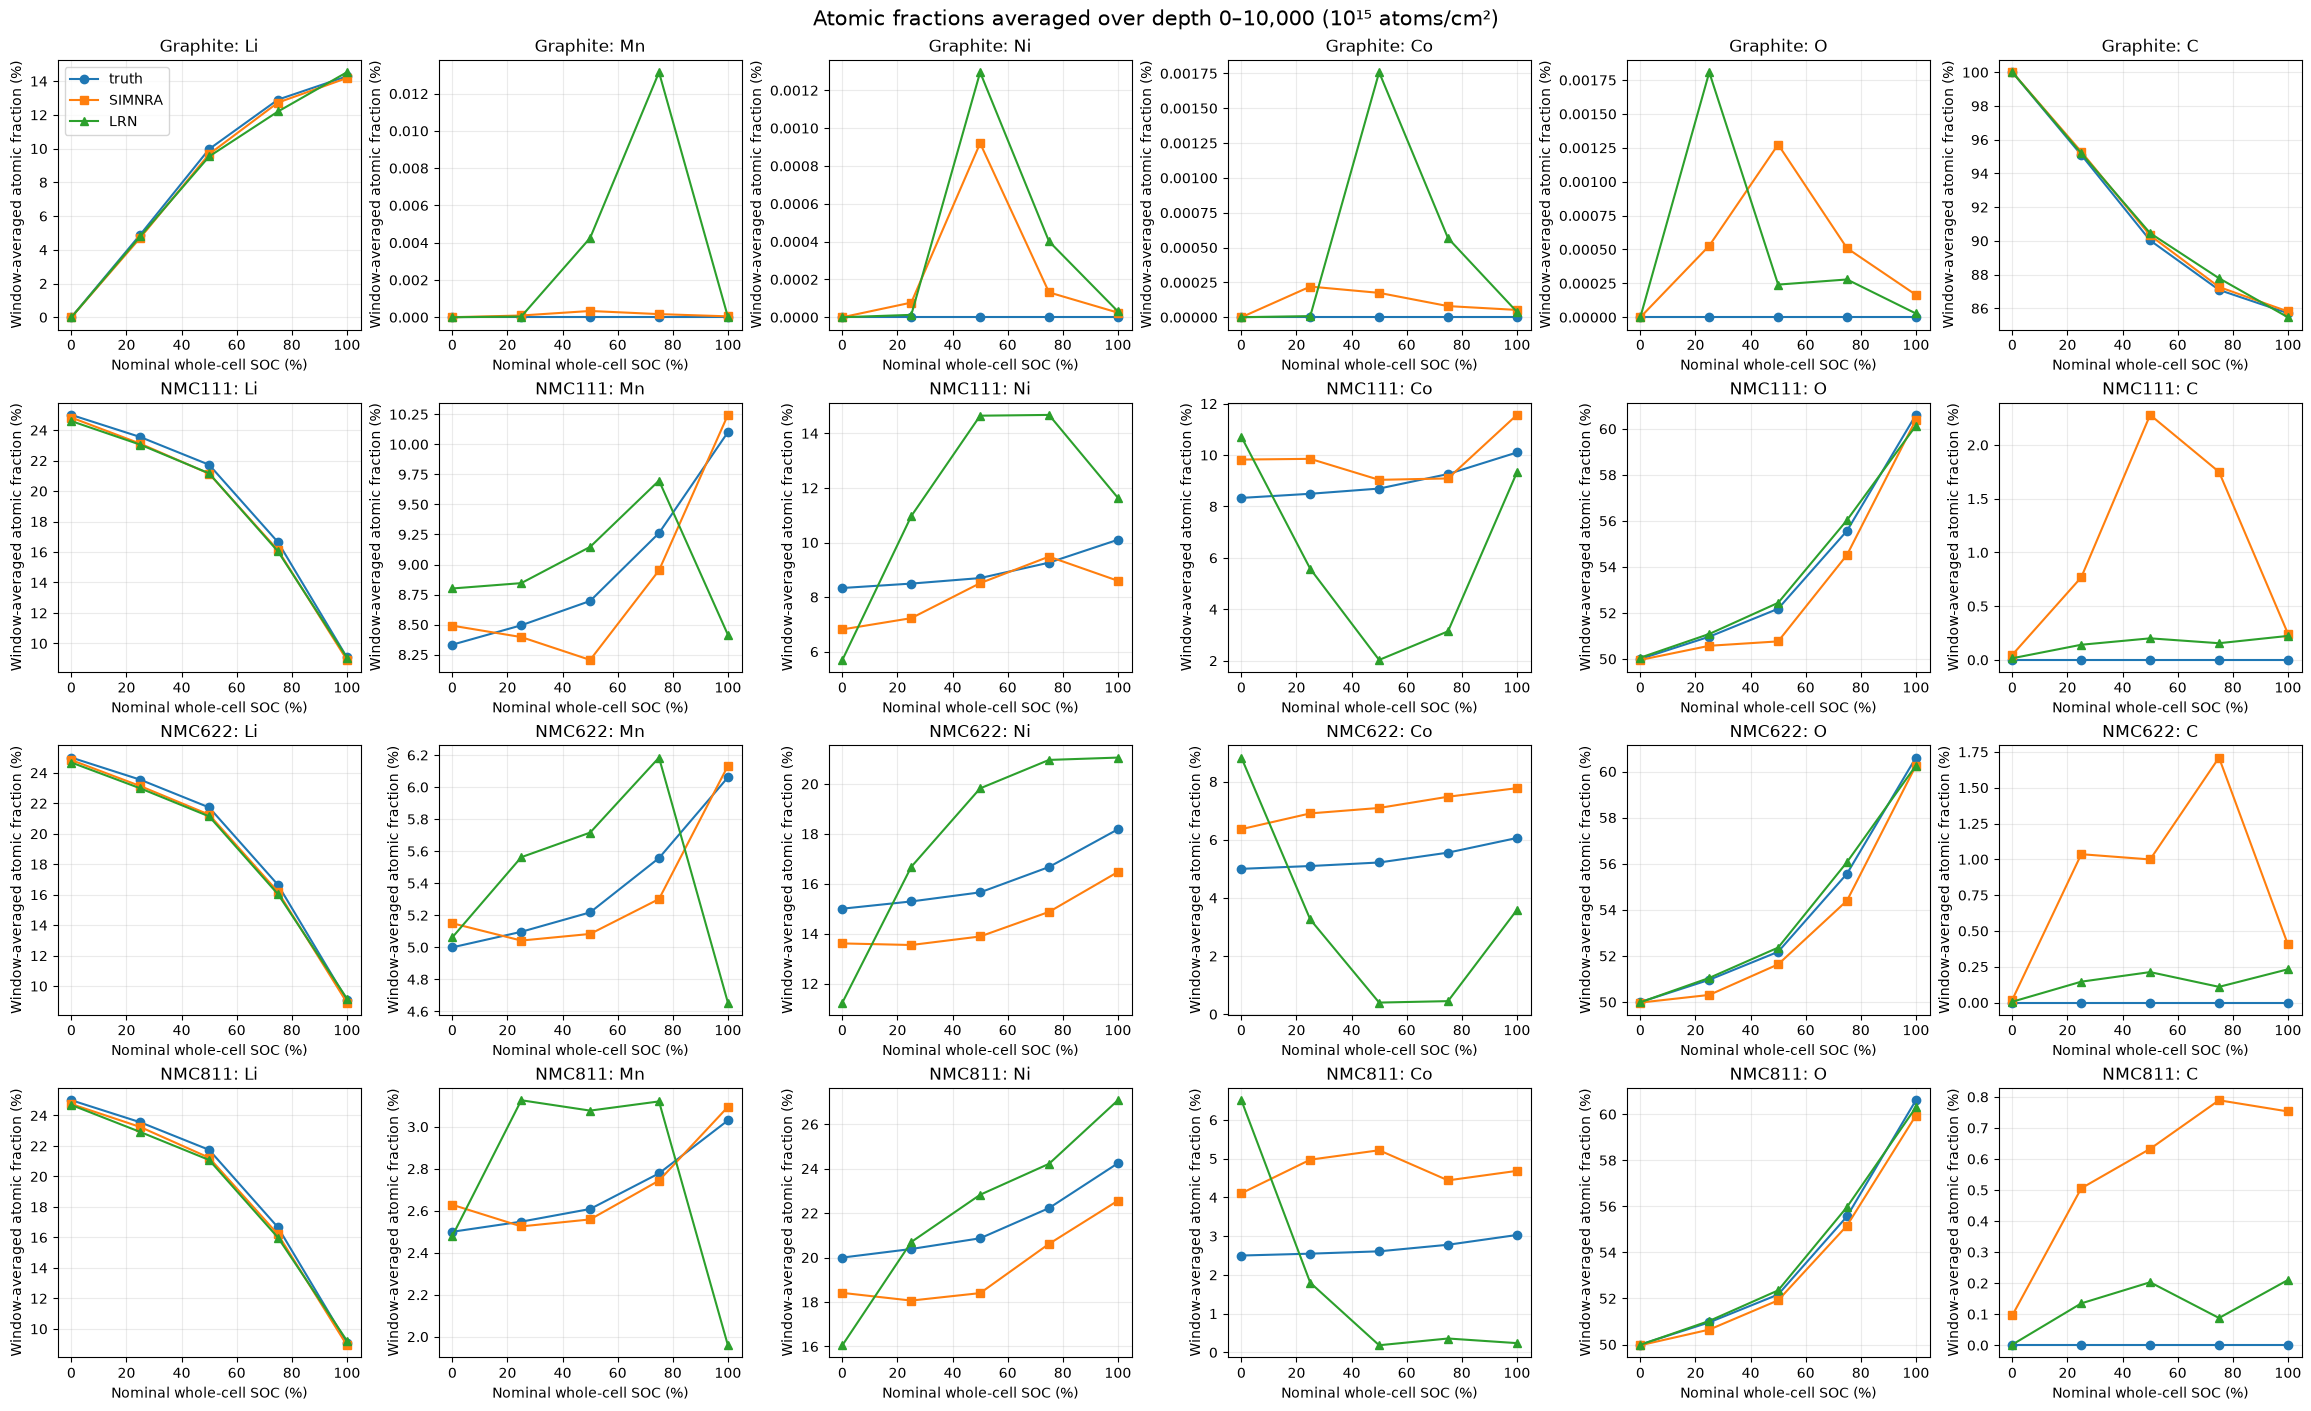

In [13]:
fig, axes = plt.subplots(4, len(species_to_check), figsize=(23, 14), constrained_layout=True)
for i, chemistry in enumerate(("Graphite", "NMC111", "NMC622", "NMC811")):
    for j, element in enumerate(species_to_check):
        ax = axes[i, j]
        selected = [r for r in window_rows if r["depth_limit"] == COMPARISON_DEPTH and r["chemistry"] == chemistry and r["element"] == element]
        for method, marker in (("truth", "o"), ("SIMNRA", "s"), ("LRN", "^")):
            ax.plot([r["nominal_soc_pct"] for r in selected], [r[method + "_atomic_pct"] for r in selected], marker=marker, label=method)
        ax.set(title=f"{chemistry}: {element}", xlabel="Nominal whole-cell SOC (%)", ylabel="Window-averaged atomic fraction (%)")
        ax.grid(alpha=.25)
        if i == 0 and j == 0:
            ax.legend()
fig.suptitle(f"Atomic fractions averaged over depth 0–{COMPARISON_DEPTH:,.0f} (10¹⁵ atoms/cm²)", fontsize=15)
fig.savefig(OUT / "element_atomic_fractions.png", dpi=180)
fig.savefig(OUT / "element_atomic_fractions_shallow.png", dpi=180)
plt.show()

## Host stoichiometry independent of lithium

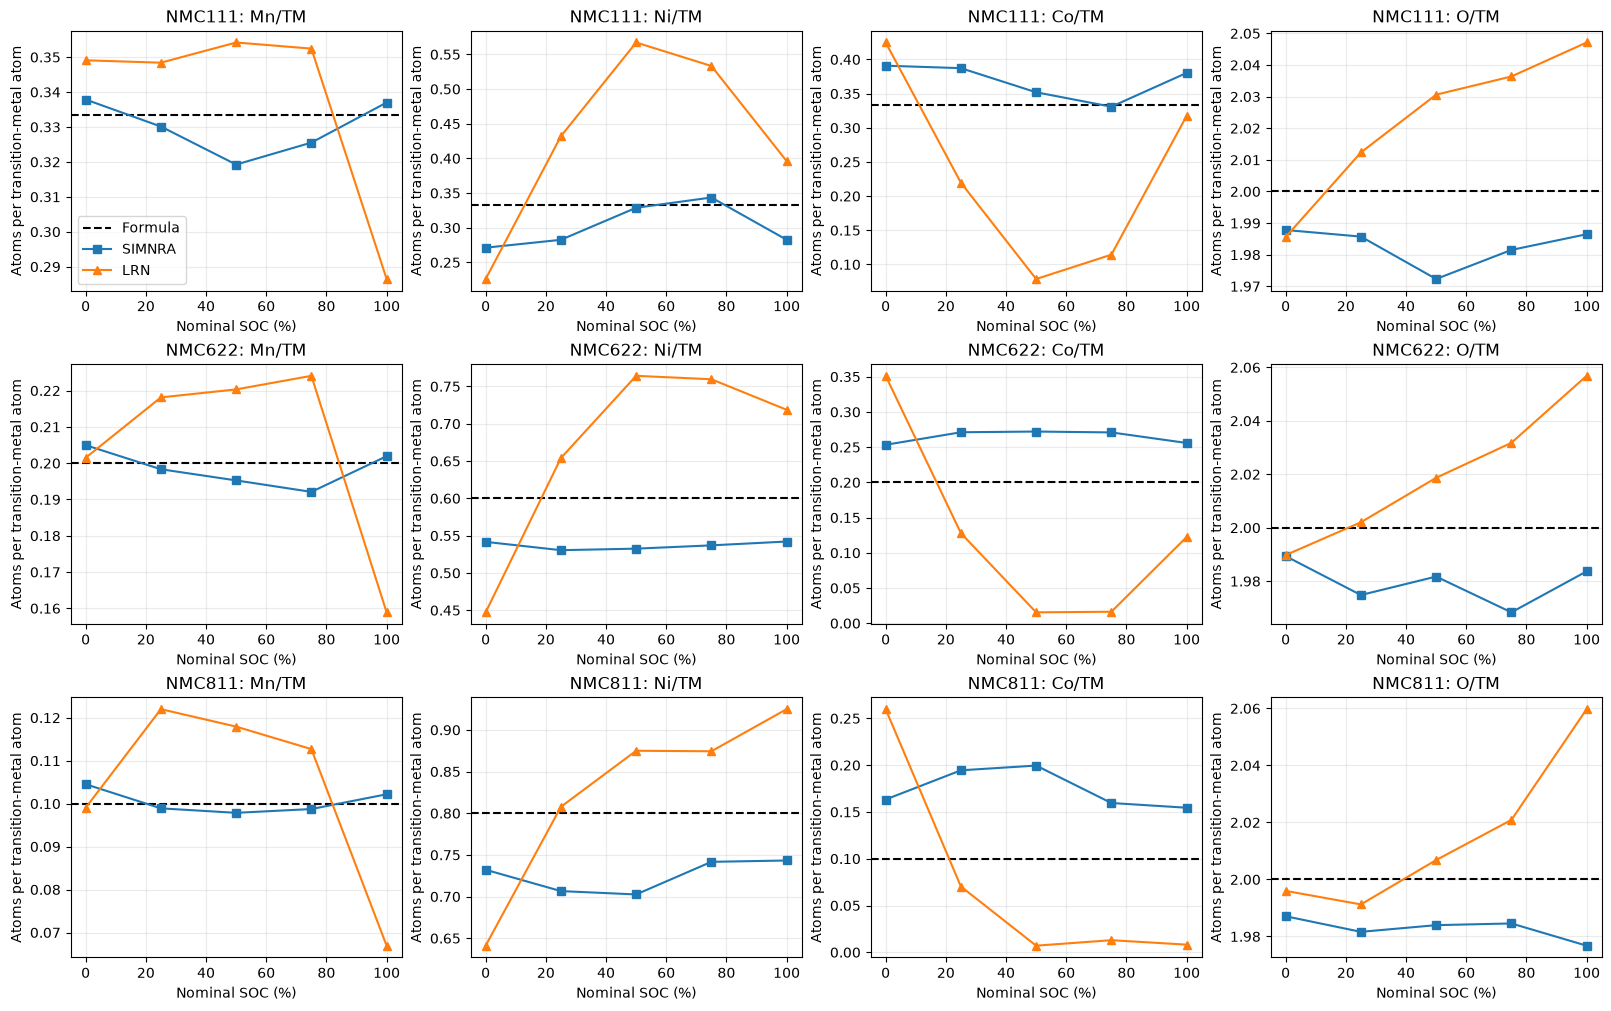

Element comparison saved to D:\iBeamLab\examples\datasets\NMC_simulated\SOC_comparison


In [14]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)
for i, chemistry in enumerate(("NMC111", "NMC622", "NMC811")):
    for j, element in enumerate(host_species):
        ax = axes[i, j]
        selected = [r for r in composition_rows if r["chemistry"] == chemistry and r["element"] == element]
        ax.axhline(selected[0]["formula_host_ratio"], color="black", linestyle="--", label="Formula")
        for method, marker in (("SIMNRA", "s"), ("LRN", "^")):
            ax.plot([r["nominal_soc_pct"] for r in selected], [r[method + "_host_ratio"] for r in selected], marker=marker, label=method)
        ax.set(title=f"{chemistry}: {element}/TM", xlabel="Nominal SOC (%)", ylabel="Atoms per transition-metal atom")
        ax.grid(alpha=.25)
        if i == 0 and j == 0:
            ax.legend()
fig.savefig(OUT / "element_host_stoichiometry.png", dpi=180)
plt.show()
print(f"Element comparison saved to {OUT}")

In [15]:
lines = ["## Element recovery findings for the currently loaded fits", "", "Errors below use the earlier full-thickness cell atomic fractions. The selected-window plot has its matching errors in the depth-window table. SOC is a separate metric based on lithium-to-host ratios.", "", "| Scope | Element | SIMNRA MAE (pp) | LRN MAE (pp) | Lower cell error |", "|---|---|---:|---:|---|"]
for scope in ("all NMC", "Graphite"):
    for element in species_to_check:
        values = {r["method"]: r["cell_atomic_mae_pp"] for r in element_metrics if r["scope"] == scope and r["element"] == element}
        winner = min(values, key=values.get)
        lines.append(f"| {scope} | {element} | {values['SIMNRA']:.3f} | {values['LRN']:.3f} | {winner} |")
lines += ["", "Pixel RMSE is reported separately above: local errors may cancel when pooling cell inventories. Host ratios are undefined for graphite and appear as NaN in exports."]
display(Markdown("\n".join(lines)))
(OUT / "current_accuracy_summary.md").write_text("\n".join(lines), encoding="utf-8")

## Element recovery findings for the currently loaded fits

Errors below use the earlier full-thickness cell atomic fractions. The selected-window plot has its matching errors in the depth-window table. SOC is a separate metric based on lithium-to-host ratios.

| Scope | Element | SIMNRA MAE (pp) | LRN MAE (pp) | Lower cell error |
|---|---|---:|---:|---|
| all NMC | Li | 0.184 | 0.282 | SIMNRA |
| all NMC | Mn | 0.150 | 0.583 | SIMNRA |
| all NMC | Ni | 1.565 | 3.071 | SIMNRA |
| all NMC | Co | 1.602 | 3.378 | SIMNRA |
| all NMC | O | 0.519 | 0.106 | LRN |
| all NMC | C | 0.660 | 0.142 | LRN |
| Graphite | Li | 0.133 | 0.130 | LRN |
| Graphite | Mn | 0.000 | 0.004 | SIMNRA |
| Graphite | Ni | 0.000 | 0.000 | SIMNRA |
| Graphite | Co | 0.000 | 0.000 | SIMNRA |
| Graphite | O | 0.000 | 0.000 | SIMNRA |
| Graphite | C | 0.132 | 0.125 | LRN |

Pixel RMSE is reported separately above: local errors may cancel when pooling cell inventories. Host ratios are undefined for graphite and appear as NaN in exports.

1017

## Laterally averaged lithium distribution versus depth

For each of the 20 cells, average the Li **atomic fraction** over all raster positions inside its circular mask, at each common areal depth. Raster positions have equal area, so use an unweighted lateral mean.

Use absolute areal depth, not depth normalized by each fitted thickness. Set **tmax = 100,000** in units of 10¹⁵ atoms/cm². Reconstruct the actual discretized layer stacks: ten generator sublayers for truth and five AutoNRA sublayers for the fits. Each sublayer has its midpoint concentration. If a fitted point is thinner than tmax, continue its **last sublayer's concentration** to tmax; if thicker, truncate at tmax. Extrapolate each point before lateral averaging.

The displayed mean is sampled every 100 depth units, including both endpoints. The extrapolated fraction of positions at each depth is exported, along with thickness statistics for each cell. These profiles use the same reconstructed concentrations as the earlier inventory analysis; extending the profiles here does not change the earlier SOC estimates.

In [16]:
TMAX = 100_000.0
DEPTH_STEP = 100.0
depth_grid = np.linspace(0.0, TMAX, int(TMAX / DEPTH_STEP) + 1)


def stack_li_on_grid(edges, li_fractions, depths):
    """Sample a piecewise-constant stack; hold its last concentration beyond T."""
    edges = np.asarray(edges, float)
    li_fractions = np.asarray(li_fractions, float)
    assert len(edges) == len(li_fractions) + 1
    assert edges[0] == 0 and np.all(np.diff(edges) > 0)
    # At an internal boundary choose the deeper sublayer; the endpoint is last.
    indices = np.searchsorted(edges[1:], depths, side="right")
    indices = np.minimum(indices, len(li_fractions) - 1)
    return li_fractions[indices]


# Check boundary selection and the requested constant tail extension.
assert np.array_equal(stack_li_on_grid([0, 20, 50], [0.1, 0.2],
                                      np.array([0, 19, 20, 50, 100])),
                      [0.1, 0.1, 0.2, 0.2, 0.2])
truth_edges = np.concatenate(([0.0], np.cumsum(thickness)))
li_index = list(elements).index("Li")
li_mean_profiles = {}
li_depth_rows = []
li_thickness_rows = []
for cell in cells:
    subset = [p for p in points if p["cell_id"] == cell["cell_id"]]
    for method in ("truth", "SIMNRA", "LRN"):
        sampled_profiles = []
        total_thicknesses = []
        for p in subset:
            if method == "truth":
                edges = truth_edges
                fractions = model["array_sublayer_compositions"](p["x_mm"], p["y_mm"])[:, li_index]
            else:
                result = fits[method][p["sample"]][1]
                edges = result["profile_edges"]
                fractions = result["profile_fractions"][:, result["profile_elements"].index("Li")]
            sampled_profiles.append(stack_li_on_grid(edges, fractions, depth_grid))
            total_thicknesses.append(edges[-1])
        totals = np.array(total_thicknesses)
        mean_profile = np.mean(sampled_profiles, axis=0)
        extrapolated = np.mean(depth_grid[None, :] > totals[:, None], axis=0)
        assert np.isfinite(mean_profile).all()
        assert np.all((mean_profile >= 0) & (mean_profile <= 1))
        li_mean_profiles[(cell["cell_id"], method)] = mean_profile
        li_thickness_rows.append({"cell_id": cell["cell_id"], "chemistry": cell["chemistry"],
            "column": cell["column"] + 1, "method": method, "n_positions": len(subset),
            "min_thickness": float(totals.min()), "mean_thickness": float(totals.mean()),
            "max_thickness": float(totals.max()), "positions_below_tmax": int(np.sum(totals < TMAX))})
        for depth, concentration, extended_fraction in zip(depth_grid, mean_profile, extrapolated):
            li_depth_rows.append({"cell_id": cell["cell_id"], "chemistry": cell["chemistry"],
                "column": cell["column"] + 1, "nominal_soc_pct": 100 * cell["soc"],
                "method": method, "depth_1e15_atoms_cm2": float(depth),
                "mean_li_atomic_fraction": float(concentration),
                "mean_li_atomic_pct": float(100 * concentration),
                "extrapolated_positions_fraction": float(extended_fraction)})
write_csv(OUT / "cell_li_depth_profiles.csv", li_depth_rows)
write_csv(OUT / "cell_li_profile_thickness.csv", li_thickness_rows)
print(f"Computed {len(cells)} cells × 3 profiles on {len(depth_grid)} depth points (0–{TMAX:,.0f}).")

Computed 20 cells × 3 profiles on 1001 depth points (0–100,000).


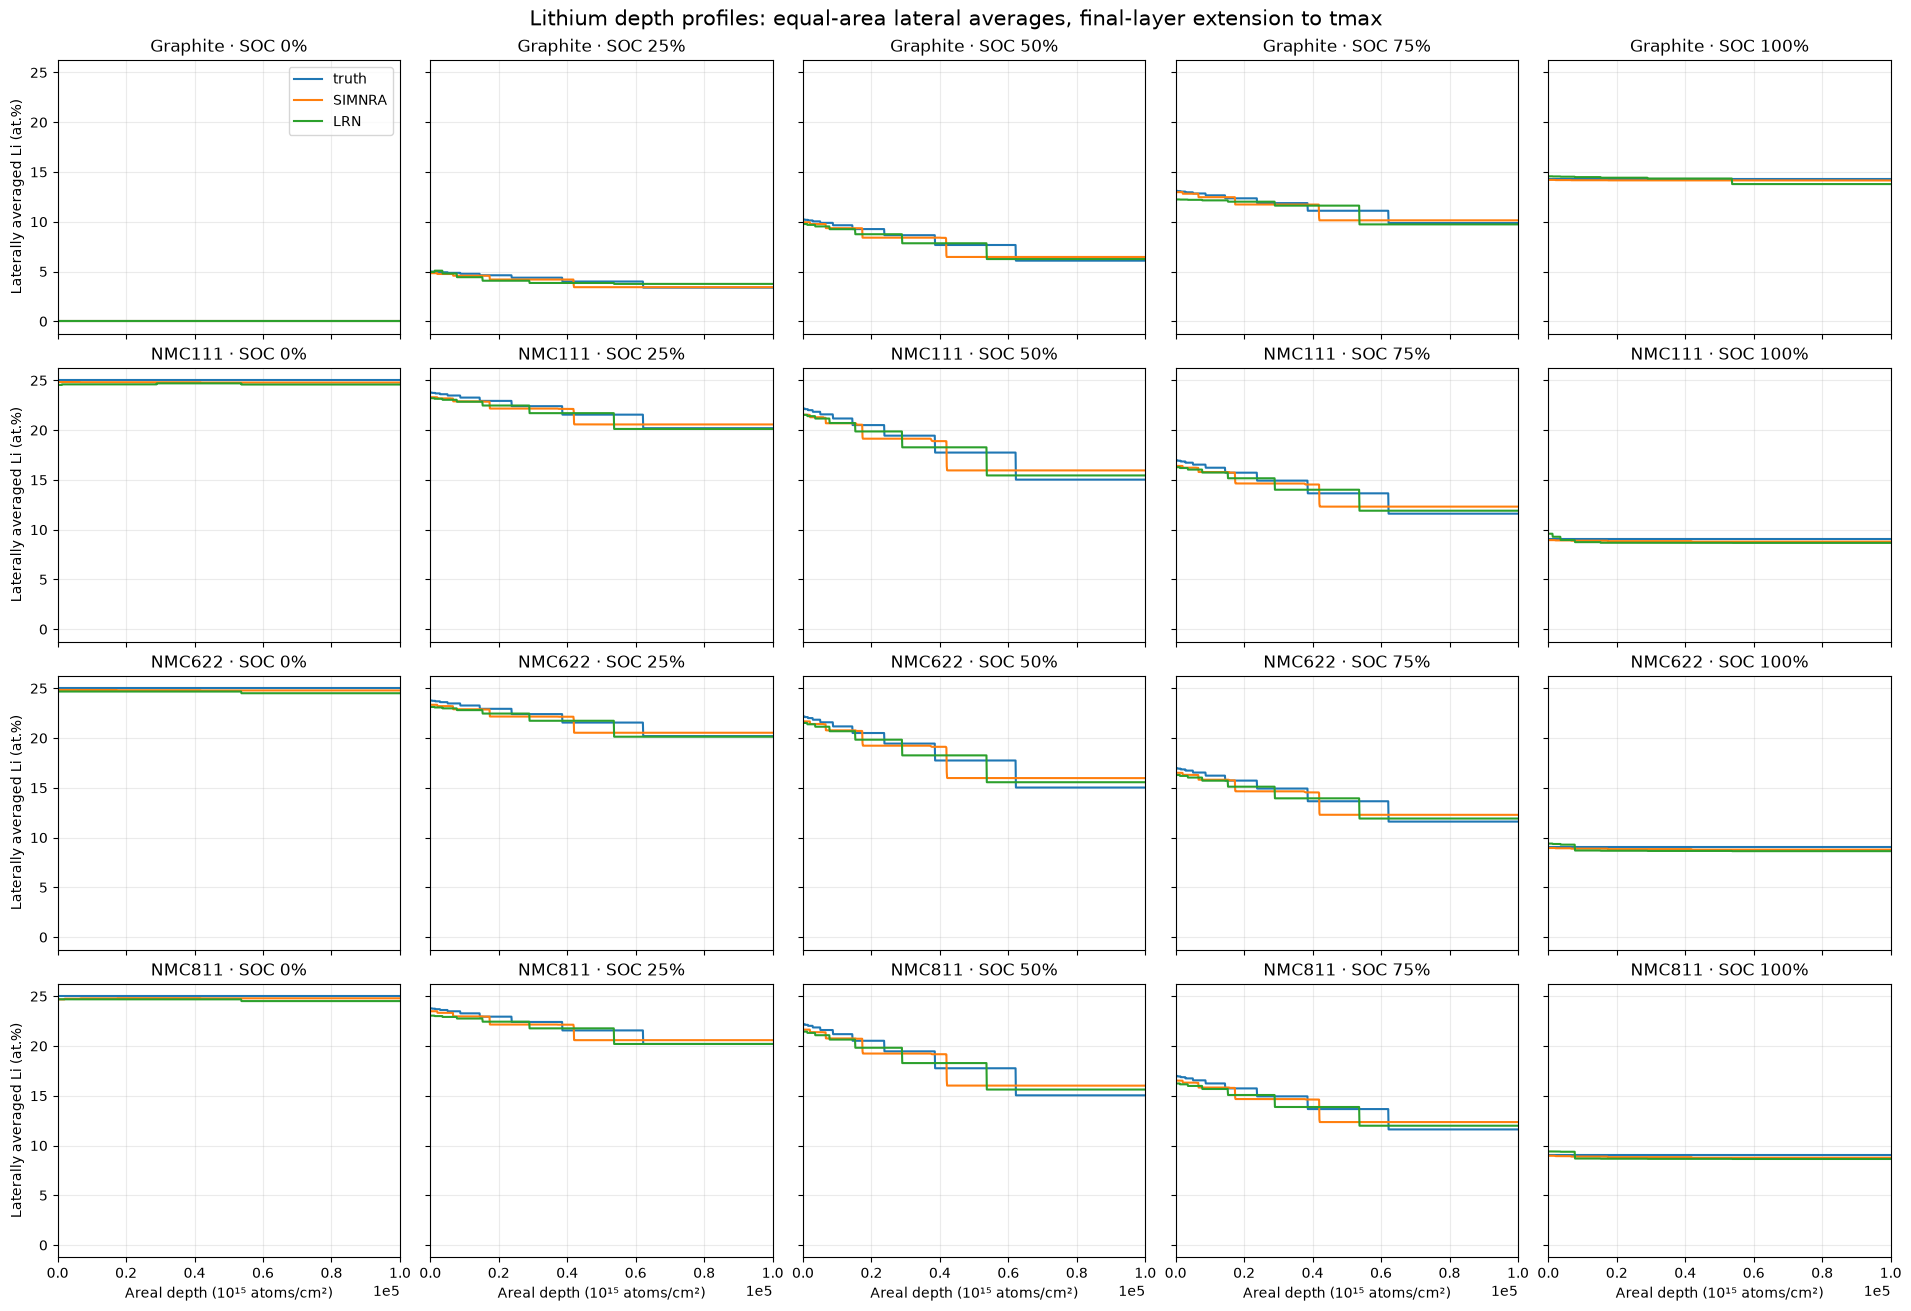

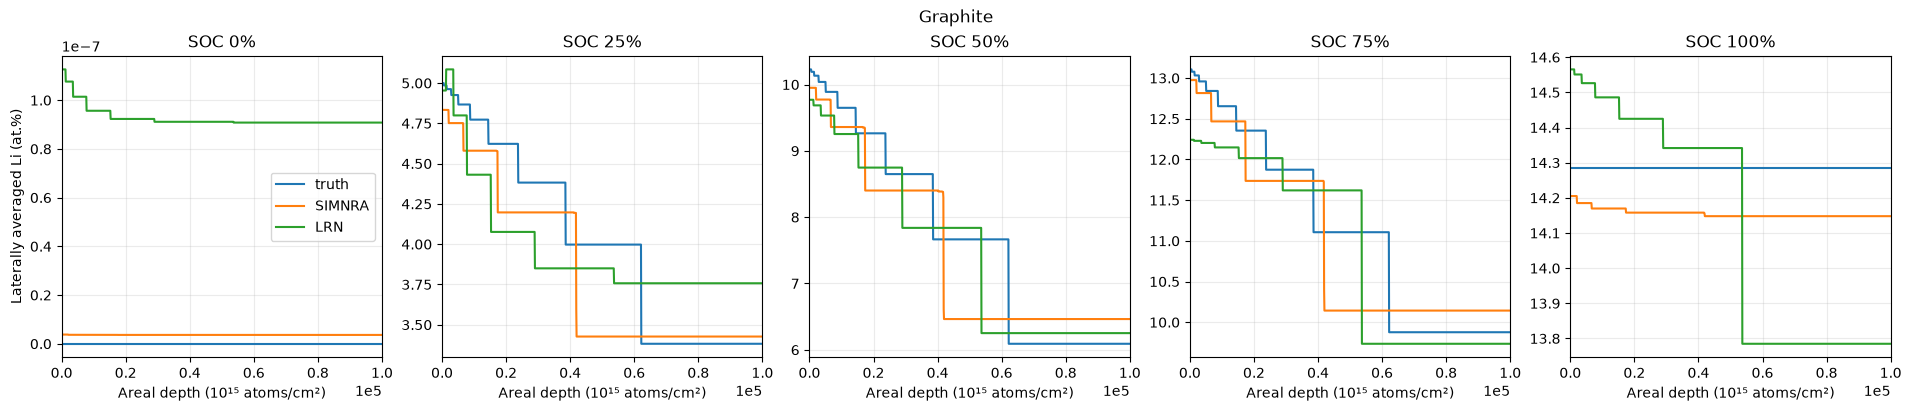

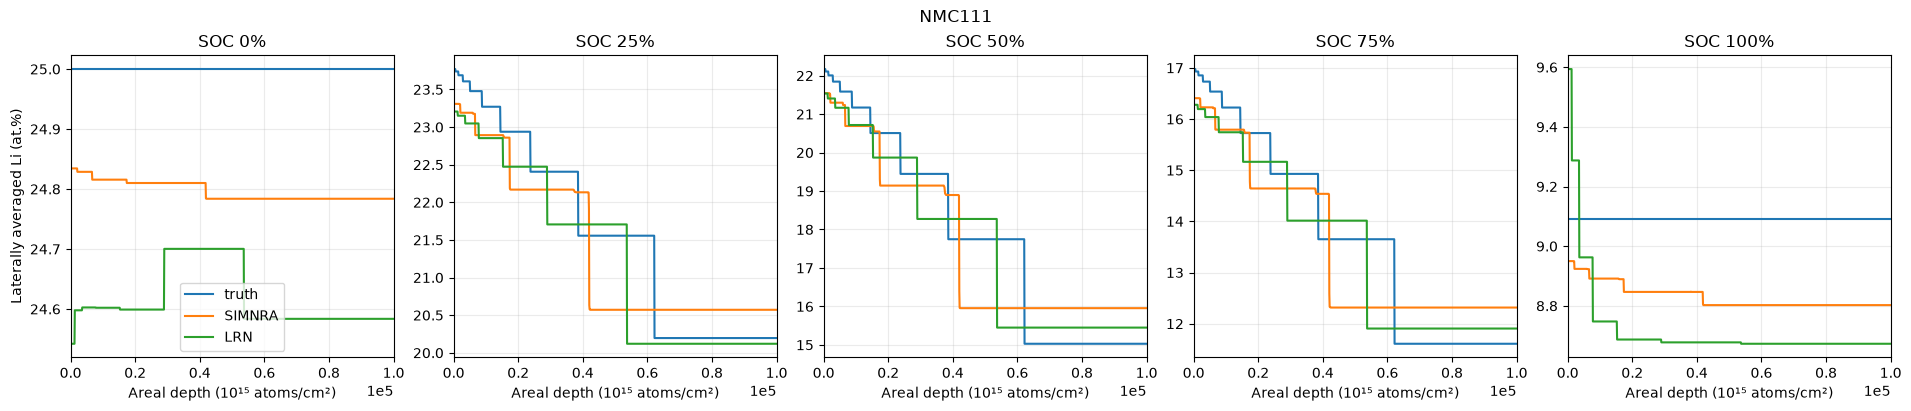

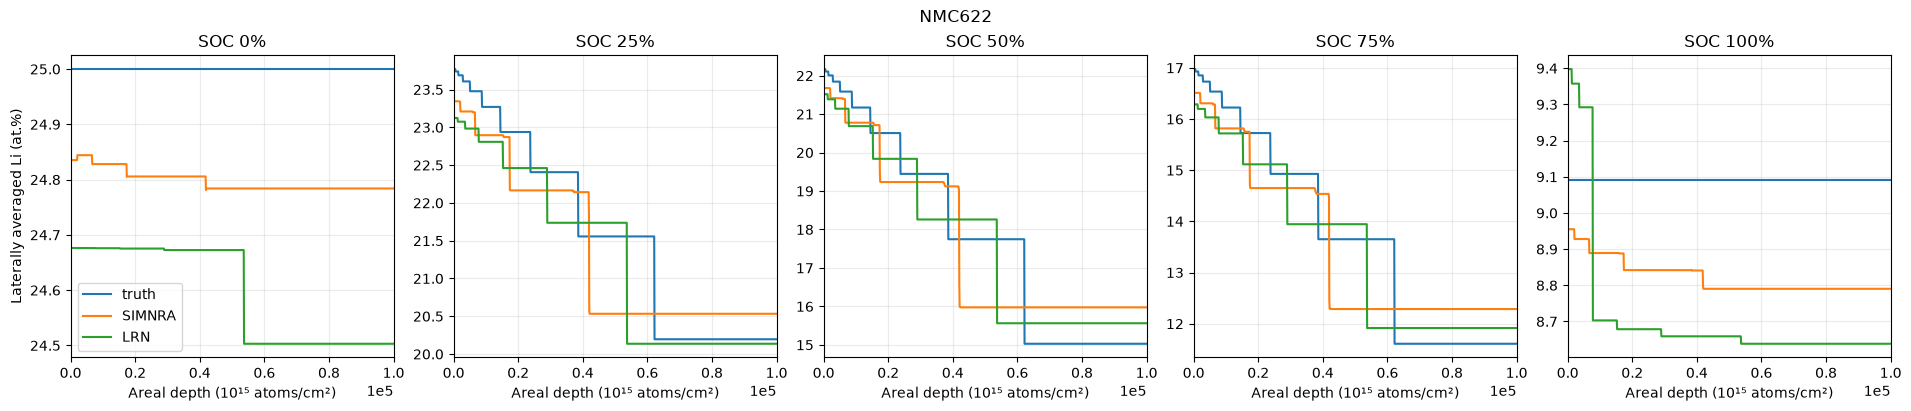

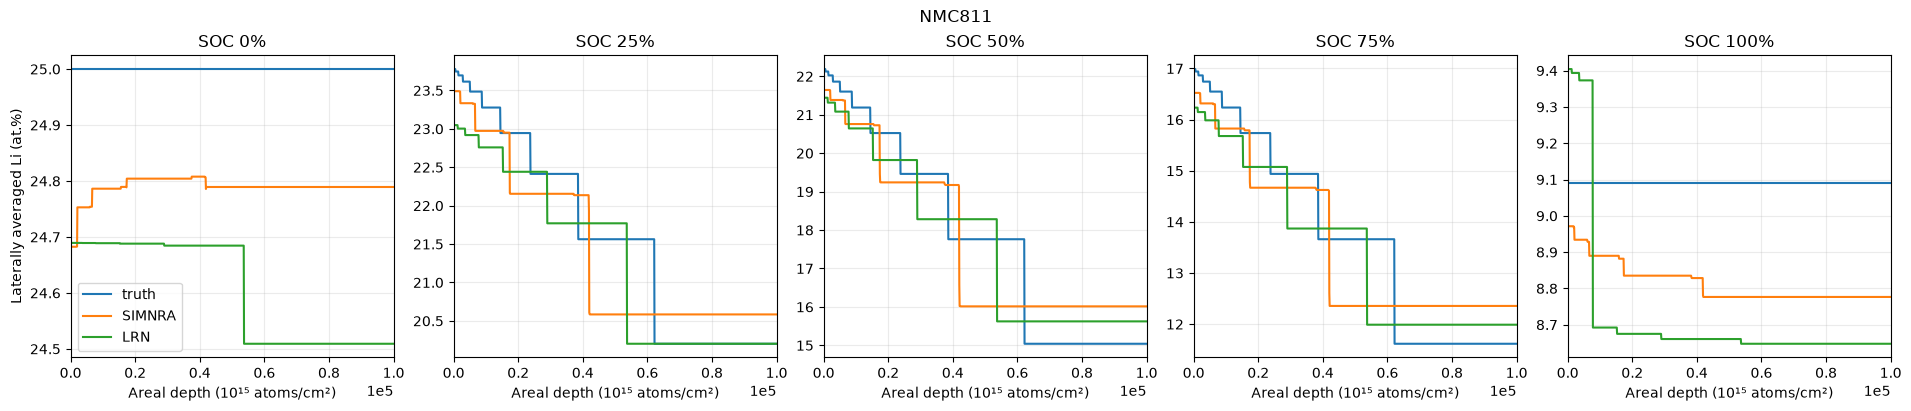

Li profiles, plots and thickness statistics saved to D:\iBeamLab\examples\datasets\NMC_simulated\SOC_comparison


In [17]:
# Shared axes allow direct comparison across cells.
fig, axes = plt.subplots(4, 5, figsize=(19, 13), sharex=True, sharey=True, constrained_layout=True)
colors = {"truth": "tab:blue", "SIMNRA": "tab:orange", "LRN": "tab:green"}
for cell in cells:
    ax = axes[cell["row"], cell["column"]]
    for method in ("truth", "SIMNRA", "LRN"):
        ax.plot(depth_grid, 100 * li_mean_profiles[(cell["cell_id"], method)],
                label=method, color=colors[method], linewidth=1.5)
    ax.set_title(f"{cell['chemistry']} · SOC {100 * cell['soc']:.0f}%")
    ax.set_xlim(0, TMAX)
    ax.grid(alpha=.25)
    ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
    if cell["column"] == 0:
        ax.set_ylabel("Laterally averaged Li (at.%)")
    if cell["row"] == 3:
        ax.set_xlabel("Areal depth (10¹⁵ atoms/cm²)")
axes[0, 0].legend()
fig.suptitle("Lithium depth profiles: equal-area lateral averages, final-layer extension to tmax", fontsize=15)
fig.savefig(OUT / "cell_li_depth_profiles.png", dpi=180)
plt.show()

# Separate row figures with independent y limits make smaller differences readable.
for chemistry in ("Graphite", "NMC111", "NMC622", "NMC811"):
    fig, axes = plt.subplots(1, 5, figsize=(19, 4), sharex=True, constrained_layout=True)
    selected = [c for c in cells if c["chemistry"] == chemistry]
    for ax, cell in zip(axes, selected):
        for method in ("truth", "SIMNRA", "LRN"):
            ax.plot(depth_grid, 100 * li_mean_profiles[(cell["cell_id"], method)],
                    label=method, color=colors[method])
        ax.set(title=f"SOC {100 * cell['soc']:.0f}%", xlabel="Areal depth (10¹⁵ atoms/cm²)")
        ax.set_xlim(0, TMAX)
        ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
        ax.grid(alpha=.25)
    axes[0].set_ylabel("Laterally averaged Li (at.%)")
    axes[0].legend()
    fig.suptitle(chemistry)
    fig.savefig(OUT / f"li_depth_profiles_{chemistry}.png", dpi=180)
    plt.show()
print(f"Li profiles, plots and thickness statistics saved to {OUT}")